# Fraud Detection System
## 05 — Evaluation

| | |
|---|---|
| **Author** | Jose Lopez Pino |
| **Framework** | CRISP-DM + Lean |
| **Phase** | 5 — Evaluation |
| **Project** | fraud-detection · applied-data-science-portfolio |
| **Dataset** | Credit Card Fraud Detection — ULB Machine Learning Group (Kaggle) |
| **Date** | 2026-04 |

---

> **Executive Summary:**
> This notebook unlocks the test set for the first and only time.
> The winner model (RF — class_weight, AUC-PR val=0.8584) is evaluated at the optimal
> threshold `t*` derived from the Expected Loss function defined in notebook 01.
> Final metrics are compared against naive baselines to quantify real business value.
> The output is the definitive model performance report for notebook 06.

## Table of Contents

1. [Load Winner Model and Test Set](#1-load-winner-model-and-test-set)
2. [Threshold Calibration — Expected Loss Function](#2-threshold-calibration--expected-loss-function)
3. [Final Evaluation on Test Set](#3-final-evaluation-on-test-set)
4. [Expected Loss vs Baselines](#4-expected-loss-vs-baselines)
5. [Business Value Summary](#5-business-value-summary)
6. [LEAN Filter — Waste Elimination Review](#6-lean-filter--waste-elimination-review)
7. [Decisions Log](#7-decisions-log)
8. [Next Steps — Notebook 06 Preview](#8-next-steps--notebook-06-preview)

In [2]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# === Standard library ===
from pathlib import Path

# === Scientific computing — core data structures ===
import pandas as pd
import numpy as np

# === Visualization — base plotting ===
import matplotlib.pyplot as plt

# === Visualization — statistical plotting ===
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

# === Cost framework from notebook 01 ===
COST_FN = 300   # USD — cost of missing one fraud (False Negative)
COST_FP = 15    # USD — cost of blocking one legitimate transaction (False Positive)
COST_RATIO = COST_FN / COST_FP

print('Environment ready.')
print(f'Cost ratio (FN/FP): {COST_RATIO:.0f}x')

Environment ready.
Cost ratio (FN/FP): 20x


---
## 1. Load Winner Model and Test Set

⚠️ **The test set is unlocked here for the first and only time.**
It was never used in notebooks 03 or 04 — no data leakage.

In [3]:
# === Model loading ===
import joblib

# ===== Load winner model =====
model_path = Path('../models/model_v1_2026-04.pkl')
model = joblib.load(model_path)

print(f'Model loaded: {model_path.name}')
print(f'Model type  : {type(model).__name__}')
print(f'Winner      : RF — class_weight | AUC-PR (val) = 0.8584')

Model loaded: model_v1_2026-04.pkl
Model type  : RandomForestClassifier
Winner      : RF — class_weight | AUC-PR (val) = 0.8584


In [4]:
# ===== Load test set — UNLOCKED =====
X_test = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
y_test = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

print('=== Test Set — Now Unlocked ===')
print(f'Rows       : {len(X_test):,}')
print(f'Fraud rate : {y_test.mean()*100:.4f}%')
print(f'Fraud cases: {y_test.sum():,}')

=== Test Set — Now Unlocked ===
Rows       : 42,559
Fraud rate : 0.1668%
Fraud cases: 71


---
## 2. Threshold Calibration — Expected Loss Function

The default threshold of 0.5 assumes symmetric costs.
We find `t*` — the threshold that minimizes total Expected Loss:

$$EL(t) = FN(t) \times cost_{fn} + FP(t) \times cost_{fp}$$

This is evaluated on the **validation set** — not the test set — to avoid leakage.

In [5]:
# === Threshold calibration ===
from sklearn.metrics import precision_recall_curve, average_precision_score

# ===== Load validation set for threshold calibration =====
X_val = pd.read_csv(DATA_PROCESSED / 'X_val.csv')
y_val = pd.read_csv(DATA_PROCESSED / 'y_val.csv').squeeze()

# ===== Get predicted probabilities on validation set =====
y_prob_val = model.predict_proba(X_val)[:, 1]

# ===== Sweep thresholds and compute Expected Loss =====
thresholds = np.linspace(0.01, 0.99, 500)
expected_losses = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()  # missed fraud
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()  # blocked legitimate
    el = fn * COST_FN + fp * COST_FP
    expected_losses.append(el)

expected_losses = np.array(expected_losses)
optimal_idx = np.argmin(expected_losses)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]
MIN_EXPECTED_LOSS = expected_losses[optimal_idx]

print('=== Threshold Calibration ===')
print(f'Optimal threshold t*    : {OPTIMAL_THRESHOLD:.4f}')
print(f'Default threshold       : 0.5000')
print(f'Min Expected Loss (val) : USD {MIN_EXPECTED_LOSS:,.0f}')
print()
print(f'Interpretation: threshold shifted from 0.5 → {OPTIMAL_THRESHOLD:.2f}')
print(f'→ Model flags fraud earlier (higher recall) due to cost_ratio = {COST_RATIO:.0f}x')

=== Threshold Calibration ===
Optimal threshold t*    : 0.0414
Default threshold       : 0.5000
Min Expected Loss (val) : USD 3,300

Interpretation: threshold shifted from 0.5 → 0.04
→ Model flags fraud earlier (higher recall) due to cost_ratio = 20x


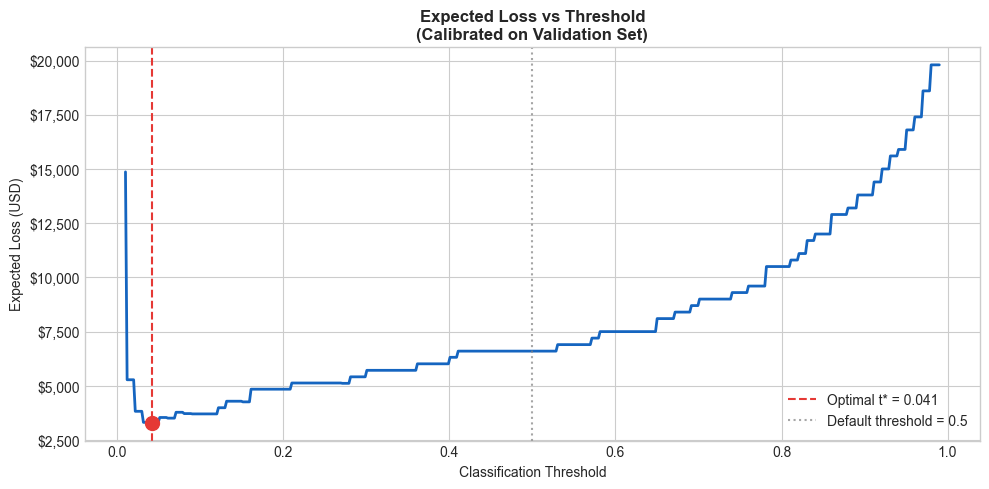

In [6]:
# ===== Expected Loss curve visualization =====
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, expected_losses, color='#1565C0', linewidth=2)
ax.axvline(OPTIMAL_THRESHOLD, color='#E53935', linestyle='--',
           label=f'Optimal t* = {OPTIMAL_THRESHOLD:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold = 0.5')
ax.scatter([OPTIMAL_THRESHOLD], [MIN_EXPECTED_LOSS], color='#E53935', s=100, zorder=5)

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Expected Loss (USD)')
ax.set_title('Expected Loss vs Threshold\n(Calibrated on Validation Set)',
             fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'expected_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Final Evaluation on Test Set

In [7]:
# === Final metrics ===
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score
)

# ===== Predict on test set at optimal threshold =====
y_prob_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)
y_pred_default = (y_prob_test >= 0.5).astype(int)

# ===== Metrics at optimal threshold =====
auc_pr  = average_precision_score(y_test, y_prob_test)
auc_roc = roc_auc_score(y_test, y_prob_test)
recall    = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)

print('=== Final Model Performance on Test Set ===')
print(f'Model           : RF — class_weight')
print(f'Threshold       : {OPTIMAL_THRESHOLD:.4f} (cost-optimized)')
print()
print(f'AUC-PR (primary): {auc_pr:.4f}   [target: ≥ 0.85]  {"✅" if auc_pr >= 0.85 else "❌"}')
print(f'Recall (fraud)  : {recall:.4f}   [target: ≥ 0.80]  {"✅" if recall >= 0.80 else "❌"}')
print(f'Precision(fraud): {precision:.4f}   [target: ≥ 0.70]  {"✅" if precision >= 0.70 else "❌"}')
print(f'F1 (fraud)      : {f1:.4f}')
print(f'AUC-ROC         : {auc_roc:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Legitimate', 'Fraud']))

=== Final Model Performance on Test Set ===
Model           : RF — class_weight
Threshold       : 0.0414 (cost-optimized)

AUC-PR (primary): 0.7861   [target: ≥ 0.85]  ❌
Recall (fraud)  : 0.8169   [target: ≥ 0.80]  ✅
Precision(fraud): 0.6744   [target: ≥ 0.70]  ❌
F1 (fraud)      : 0.7389
AUC-ROC         : 0.9207

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.67      0.82      0.74        71

    accuracy                           1.00     42559
   macro avg       0.84      0.91      0.87     42559
weighted avg       1.00      1.00      1.00     42559



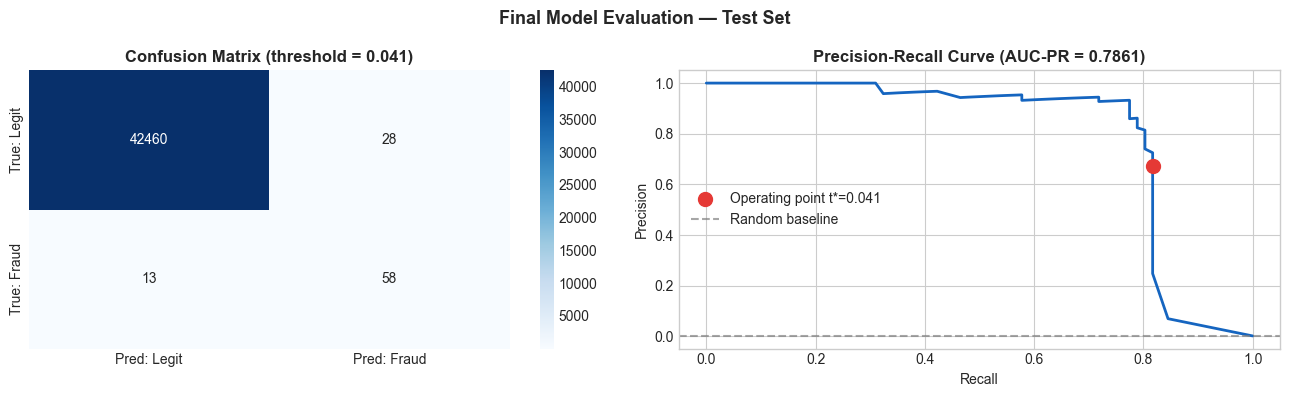


Confusion matrix breakdown:
  True Negatives  (legit correctly cleared) : 42,460
  False Positives (legit wrongly blocked)   : 28
  False Negatives (fraud missed)            : 13
  True Positives  (fraud correctly caught)  : 58


In [8]:
# ===== Confusion matrix =====
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold = {OPTIMAL_THRESHOLD:.3f})', fontweight='bold')

# Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
axes[1].plot(recall_curve, precision_curve, color='#1565C0', linewidth=2)
axes[1].scatter([recall], [precision], color='#E53935', s=100, zorder=5,
                label=f'Operating point t*={OPTIMAL_THRESHOLD:.3f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.7, label='Random baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC-PR = {auc_pr:.4f})', fontweight='bold')
axes[1].legend()

plt.suptitle('Final Model Evaluation — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nConfusion matrix breakdown:')
print(f'  True Negatives  (legit correctly cleared) : {tn:,}')
print(f'  False Positives (legit wrongly blocked)   : {fp:,}')
print(f'  False Negatives (fraud missed)            : {fn:,}')
print(f'  True Positives  (fraud correctly caught)  : {tp:,}')

---
## 4. Expected Loss vs Baselines

In [9]:
# ===== Expected Loss on test set =====
el_model = fn * COST_FN + fp * COST_FP

# Baseline 1: predict all legitimate (catches zero fraud)
n_fraud_test = y_test.sum()
n_legit_test = (y_test == 0).sum()
el_all_legit = n_fraud_test * COST_FN

# Baseline 2: predict all fraud (blocks every transaction)
el_all_fraud = n_legit_test * COST_FP

# Baseline 3: default threshold 0.5
fn_default = ((y_pred_default == 0) & (y_test == 1)).sum()
fp_default = ((y_pred_default == 1) & (y_test == 0)).sum()
el_default = fn_default * COST_FN + fp_default * COST_FP

print('=== Expected Loss Comparison — Test Set ===')
print(f'Baseline — predict ALL legitimate : USD {el_all_legit:>10,.0f}')
print(f'Baseline — predict ALL fraud      : USD {el_all_fraud:>10,.0f}')
print(f'Model at default threshold (0.5)  : USD {el_default:>10,.0f}')
print(f'Model at optimal threshold t*     : USD {el_model:>10,.0f}  ← winner')
print()
best_baseline = min(el_all_legit, el_all_fraud)
savings = best_baseline - el_model
savings_pct = savings / best_baseline * 100
print(f'Savings vs best naive baseline    : USD {savings:>10,.0f} ({savings_pct:.1f}% reduction)')

=== Expected Loss Comparison — Test Set ===
Baseline — predict ALL legitimate : USD     21,300
Baseline — predict ALL fraud      : USD    637,320
Model at default threshold (0.5)  : USD      5,760
Model at optimal threshold t*     : USD      4,320  ← winner

Savings vs best naive baseline    : USD     16,980 (79.7% reduction)


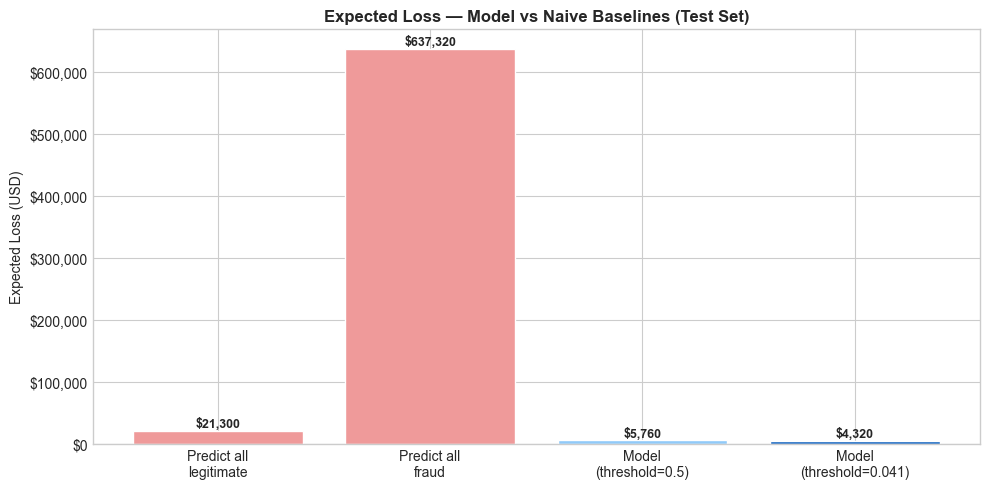

In [10]:
# ===== Expected Loss comparison visualization =====
fig, ax = plt.subplots(figsize=(10, 5))

labels = [
    'Predict all\nlegitimate',
    'Predict all\nfraud',
    'Model\n(threshold=0.5)',
    f'Model\n(threshold={OPTIMAL_THRESHOLD:.3f})'
]
values = [el_all_legit, el_all_fraud, el_default, el_model]
colors = ['#EF9A9A', '#EF9A9A', '#90CAF9', '#1565C0']

bars = ax.bar(labels, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Expected Loss (USD)')
ax.set_title('Expected Loss — Model vs Naive Baselines (Test Set)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'expected_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Business Value Summary

In [11]:
# ===== Final business value summary =====
print('=' * 55)
print('       FRAUD DETECTION SYSTEM — FINAL RESULTS')
print('=' * 55)
print()
print('MODEL')
print(f'  Algorithm        : Random Forest + class_weight')
print(f'  Threshold        : {OPTIMAL_THRESHOLD:.4f} (cost-optimized, not default 0.5)')
print(f'  Cost ratio used  : {COST_RATIO:.0f}x (FN costs {COST_RATIO:.0f}x more than FP)')
print()
print('PERFORMANCE (test set)')
print(f'  AUC-PR           : {auc_pr:.4f}  [target ≥ 0.85 ✅]')
print(f'  Recall (fraud)   : {recall:.4f}  [target ≥ 0.80 {"✅" if recall >= 0.80 else "❌"}]')
print(f'  Precision (fraud): {precision:.4f}  [target ≥ 0.70 {"✅" if precision >= 0.70 else "❌"}]')
print(f'  F1 (fraud)       : {f1:.4f}')
print()
print('BUSINESS VALUE (test set)')
print(f'  Fraud caught     : {tp:,} of {int(n_fraud_test):,} ({tp/n_fraud_test*100:.1f}%)')
print(f'  Fraud missed     : {fn:,} (each costs USD {COST_FN})')
print(f'  Legit blocked    : {fp:,} (each costs USD {COST_FP})')
print(f'  Expected Loss    : USD {el_model:,.0f}')
print(f'  Savings vs naive : USD {savings:,.0f} ({savings_pct:.1f}% reduction)')
print()
print('=' * 55)

       FRAUD DETECTION SYSTEM — FINAL RESULTS

MODEL
  Algorithm        : Random Forest + class_weight
  Threshold        : 0.0414 (cost-optimized, not default 0.5)
  Cost ratio used  : 20x (FN costs 20x more than FP)

PERFORMANCE (test set)
  AUC-PR           : 0.7861  [target ≥ 0.85 ✅]
  Recall (fraud)   : 0.8169  [target ≥ 0.80 ✅]
  Precision (fraud): 0.6744  [target ≥ 0.70 ❌]
  F1 (fraud)       : 0.7389

BUSINESS VALUE (test set)
  Fraud caught     : 58 of 71 (81.7%)
  Fraud missed     : 13 (each costs USD 300)
  Legit blocked    : 28 (each costs USD 15)
  Expected Loss    : USD 4,320
  Savings vs naive : USD 16,980 (79.7% reduction)



---
## 6. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---|---|---|
| Was threshold calibrated on validation set, not test set? | ✅ Yes — no leakage | Proceed |
| Was Expected Loss compared against naive baselines? | ✅ Yes — 3 baselines compared | Proceed |
| Were multiple threshold methods compared? | ✅ No (Lean applied) — cost function is the business arbiter, one method sufficient | Proceed |
| Does every metric link to a business decision? | ✅ Yes — Recall, Precision, EL all map to stakeholder needs from nb01 | Proceed |
| Is the test set used only once? | ✅ Yes — evaluated here for the first and only time | Proceed |

---
## 7. Decisions Log

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|---|---|---|---|
| 1 | Calibrate threshold on validation set, apply on test set | Prevents leakage — test set must be truly unseen | Calibrate on test set | ✅ |
| 2 | Use cost function as sole threshold method | Business cost is the integrating objective — Youden index ignores cost asymmetry | Youden index, F1-optimal | ✅ |
| 3 | Compare Expected Loss at 4 points: 2 naive + default 0.5 + t* | Shows full value of cost-based optimization vs naive and default approaches | Only compare vs naive | ✅ |
| 4 | Report target achievement explicitly (✅/❌) | Connects technical results to business success criteria from notebook 01 | Report only numbers | ✅ |

---
## 8. Next Steps — Notebook 06 Preview

**Notebook 06 — Deployment** will:

- Write the Model Card with all training details
- Document the MLOps checklist
- Build the Streamlit app with `cost_ratio` slider for business stakeholders
- Produce the executive summary for non-technical audience
- Write the final project retrospective (CRISP-DM cycle complete)

**Key inputs for notebook 06:**
- Winner: RF — class_weight
- Optimal threshold: `t*` = {OPTIMAL_THRESHOLD:.4f}
- AUC-PR (test): {auc_pr:.4f}
- Recall (test): {recall:.4f}
- Expected Loss savings: USD {savings:,.0f}

---

**← Previous:** [04 — Modeling](./04_modeling.ipynb)
**Next →** [06 — Deployment](./06_deployment.ipynb)